In [2]:
import numpy as np
import pandas as pd
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [3]:
X, y = fetch_openml(
    'Fashion-MNIST',
    version=1,
    return_X_y=True,
    as_frame=False
)

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

Dataset shape: (70000, 784)
Target shape: (70000,)


In [4]:
X = X / 255.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 56000
Testing samples: 14000


In [6]:
start_time = time.time()

linear_svm = SVC(
    kernel='linear',
    C=1
)

linear_svm.fit(X_train, y_train)

linear_time = time.time() - start_time

y_pred_linear = linear_svm.predict(X_test)

linear_accuracy = accuracy_score(y_test, y_pred_linear)

linear_precision = precision_score(
    y_test, y_pred_linear, average='weighted'
)

linear_recall = recall_score(
    y_test, y_pred_linear, average='weighted'
)

linear_f1 = f1_score(
    y_test, y_pred_linear, average='weighted'
)

print("Linear SVM")
print("Accuracy :", linear_accuracy)
print("Precision:", linear_precision)
print("Recall   :", linear_recall)
print("F1 Score :", linear_f1)
print("Training Time:", linear_time)

Linear SVM
Accuracy : 0.8522142857142857
Precision: 0.8513077845920402
Recall   : 0.8522142857142857
F1 Score : 0.8510364496004058
Training Time: 177.4356713294983


In [7]:
start_time = time.time()

poly_svm = SVC(
    kernel='poly',
    degree=3,
    C=1,
    gamma='scale'
)

poly_svm.fit(X_train, y_train)

poly_time = time.time() - start_time

y_pred_poly = poly_svm.predict(X_test)

poly_accuracy = accuracy_score(y_test, y_pred_poly)

poly_precision = precision_score(
    y_test, y_pred_poly, average='weighted'
)

poly_recall = recall_score(
    y_test, y_pred_poly, average='weighted'
)

poly_f1 = f1_score(
    y_test, y_pred_poly, average='weighted'
)

print("Polynomial SVM")
print("Accuracy :", poly_accuracy)
print("Precision:", poly_precision)
print("Recall   :", poly_recall)
print("F1 Score :", poly_f1)
print("Training Time:", poly_time)

Polynomial SVM
Accuracy : 0.8653571428571428
Precision: 0.8676892001439718
Recall   : 0.8653571428571428
F1 Score : 0.865609193381687
Training Time: 191.64548349380493


In [8]:
start_time = time.time()

rbf_svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

rbf_svm.fit(X_train, y_train)

rbf_time = time.time() - start_time

y_pred_rbf = rbf_svm.predict(X_test)

rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

rbf_precision = precision_score(
    y_test, y_pred_rbf, average='weighted'
)

rbf_recall = recall_score(
    y_test, y_pred_rbf, average='weighted'
)

rbf_f1 = f1_score(
    y_test, y_pred_rbf, average='weighted'
)

print("RBF SVM")
print("Accuracy :", rbf_accuracy)
print("Precision:", rbf_precision)
print("Recall   :", rbf_recall)
print("F1 Score :", rbf_f1)
print("Training Time:", rbf_time)

RBF SVM
Accuracy : 0.8883571428571428
Precision: 0.8877726841869988
Recall   : 0.8883571428571428
F1 Score : 0.8874723698451407
Training Time: 151.3803277015686


In [9]:
results = pd.DataFrame({
    'Kernel': ['Linear', 'Polynomial', 'RBF'],
    'Accuracy': [
        linear_accuracy,
        poly_accuracy,
        rbf_accuracy
    ],
    'Precision': [
        linear_precision,
        poly_precision,
        rbf_precision
    ],
    'Recall': [
        linear_recall,
        poly_recall,
        rbf_recall
    ],
    'F1 Score': [
        linear_f1,
        poly_f1,
        rbf_f1
    ],
    'Training Time (s)': [
        linear_time,
        poly_time,
        rbf_time
    ]
})

print(results)

       Kernel  Accuracy  Precision    Recall  F1 Score  Training Time (s)
0      Linear  0.852214   0.851308  0.852214  0.851036         177.435671
1  Polynomial  0.865357   0.867689  0.865357  0.865609         191.645483
2         RBF  0.888357   0.887773  0.888357  0.887472         151.380328


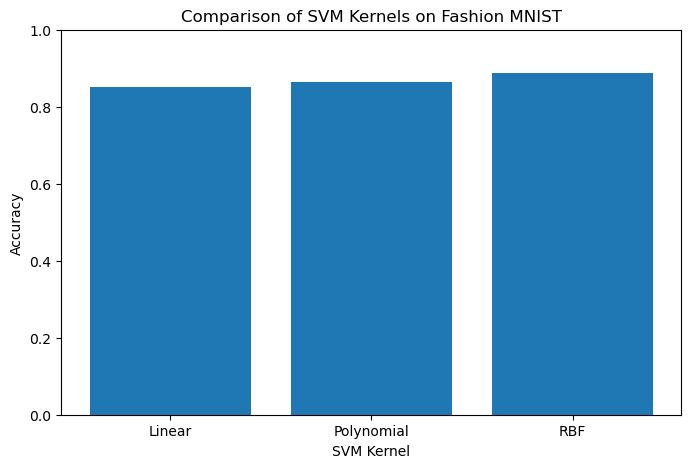

In [10]:
import matplotlib.pyplot as plt

kernels = ['Linear', 'Polynomial', 'RBF']

accuracies = [
    linear_accuracy,
    poly_accuracy,
    rbf_accuracy
]

plt.figure(figsize=(8, 5))

plt.bar(kernels, accuracies)

plt.xlabel("SVM Kernel")
plt.ylabel("Accuracy")
plt.title("Comparison of SVM Kernels on Fashion MNIST")
plt.ylim(0, 1)

plt.show()